In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import time

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas.")

✅ Librerías cargadas.


In [2]:
# 1. Cargar tus CSVs limpios
folder = ''
df_bin = pd.read_csv('csv/binCL1sec.csv')
df_8 = pd.read_csv('csv/C8CL1sec.csv')
df_60 = pd.read_csv('csv/C60CL1sec.csv')

# 2. Definir columna objetivo
target_col = 'target' 

# 3. Extraer características (X) - Tomamos las del binario como base
X_all = df_bin.drop(columns=[target_col])
feature_names = X_all.columns.tolist()

# 4. Generar sets de TEST (usando el mismo random_state que en entrenamiento)
# Esto garantiza que evaluamos exactamente las mismas filas en las 3 tareas
indices = range(len(df_bin))
_, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_test_raw = X_all.iloc[test_idx]
y_test_bin = df_bin[target_col].iloc[test_idx]
y_test_8 = df_8[target_col].iloc[test_idx]
y_test_60 = df_60[target_col].iloc[test_idx]

print(f"✅ Datos listos. Muestras de test: {len(X_test_raw)}")

✅ Datos listos. Muestras de test: 45439


In [3]:
# Configuración de diccionarios
tareas = {
    "Binaria": {"prefix": "2clases", "y_real": y_test_bin},
    "8-Clases": {"prefix": "8clases", "y_real": y_test_8},
    "60-Clases": {"prefix": "60clases", "y_real": y_test_60}
}
algoritmos = ["RandomForest", "kNN", "MLP", "NaiveBayes"]

scalers = {}
modelos = {t: {} for t in tareas}
folder = 'joblibs/03032026'

# Bucle de carga (Ajusta los nombres si tus archivos se llaman distinto)
for t, info in tareas.items():
    pfx = info["prefix"]
    scalers[t] = joblib.load(f"{folder}/{pfx}/scaler_final.joblib")
    
    for alg in algoritmos:
        path = f"{folder}/{pfx}/{alg}.joblib"
        if os.path.exists(path):
            modelos[t][alg] = joblib.load(path)
        else:
            print(f"⚠️ No se encontró: {path}")

print("✅ Modelos y Scalers cargados en memoria.")

✅ Modelos y Scalers cargados en memoria.


In [ ]:
resultados_master = []

for t, info in tareas.items():
    # 1. Aplicar el scaler específico de la tarea
    X_test_scaled = scalers[t].transform(X_test_raw)
    
    for alg, modelo in modelos[t].items():
        # 2. Predicción
        start = time.time()
        y_pred = modelo.predict(X_test_scaled)
        end = time.time()
        
        # 3. Cálculo de métricas
        resultados_master.append({
            "Tarea": t,
            "Algoritmo": alg,
            "Accuracy": accuracy_score(info["y_real"], y_pred),
            "F1-Score": f1_score(info["y_real"], y_pred, average='weighted'),
            "Recall": recall_score(info["y_real"], y_pred, average='weighted'),
            "Tiempo de test": (end - start)
        })

df_comparativa = pd.DataFrame(resultados_master)
display(df_comparativa.sort_values(by=["Tarea", "F1-Score"], ascending=[True, False]))

,Tarea,Algoritmo,Accuracy,F1-Score,Recall
9,60-Clases,kNN,0.852043,0.838000,0.852043
10,60-Clases,MLP,0.804485,0.781801,0.804485
8,60-Clases,RandomForest,0.804199,0.780674,0.804199
11,60-Clases,NaiveBayes,0.091309,0.117105,0.091309
6,8-Clases,MLP,0.917054,0.913750,0.917054
5,8-Clases,kNN,0.914743,0.911383,0.914743
4,8-Clases,RandomForest,0.860164,0.846619,0.860164
7,8-Clases,NaiveBayes,0.139088,0.082406,0.139088
2,Binaria,MLP,0.931865,0.930785,0.931865
1,Binaria,kNN,0.930742,0.929615,0.930742


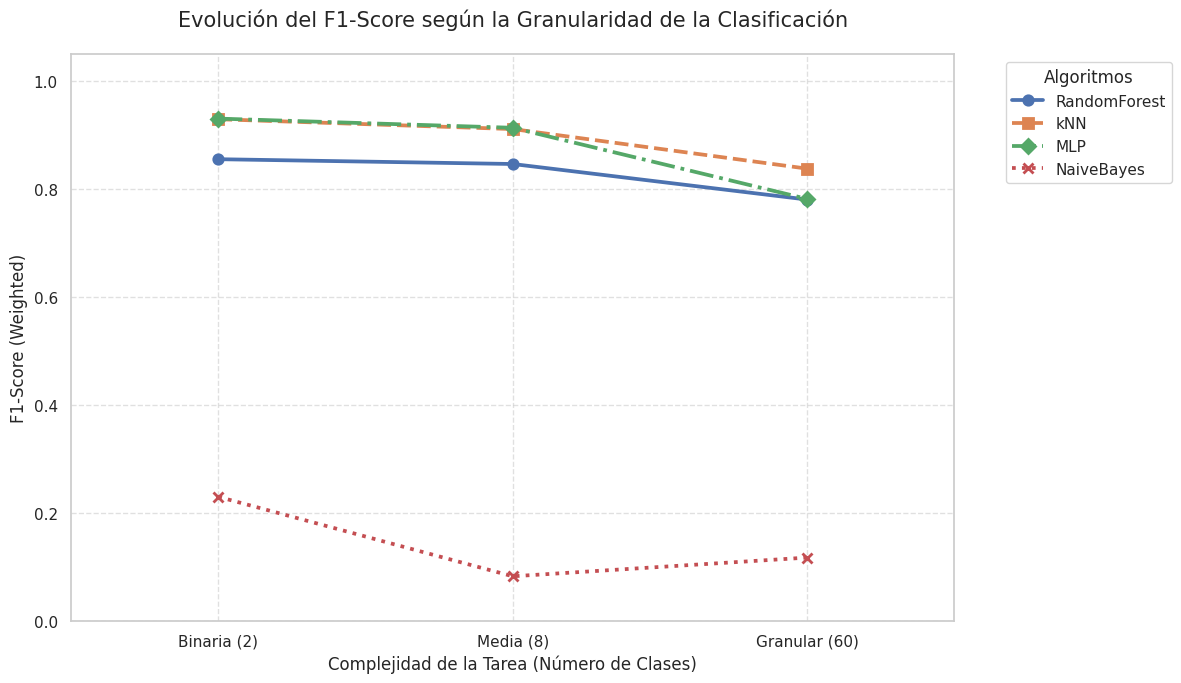

In [5]:
df_plot = df_comparativa.copy()

# Limpiamos los nombres de las tareas para que el orden sea natural
# (Quitamos los números que puso Pandas en el índice si es necesario)
mapeo_tareas = {
    "Binaria": "Binaria (2)",
    "8-Clases": "Media (8)",
    "60-Clases": "Granular (60)"
}
df_plot['Tarea_Limpia'] = df_plot['Tarea'].map(mapeo_tareas)

# 2. Configuración de la gráfica
plt.figure(figsize=(12, 7))

# Usamos pointplot para ver la tendencia (líneas que conectan los puntos)
sns.pointplot(
    data=df_plot, 
    x="Tarea_Limpia", 
    y="F1-Score", 
    hue="Algoritmo",
    markers=["o", "s", "D", "x"], # Diferentes formas para cada algoritmo
    linestyles=["-", "--", "-.", ":"],
    order=["Binaria (2)", "Media (8)", "Granular (60)"] # Forzamos el orden de complejidad
)

# 3. Estética profesional para el TFG
plt.title("Evolución del F1-Score según la Granularidad de la Clasificación", fontsize=15, pad=20)
plt.xlabel("Complejidad de la Tarea (Número de Clases)", fontsize=12)
plt.ylabel("F1-Score (Weighted)", fontsize=12)
plt.ylim(0, 1.05) # El límite superior un poco más de 1 para que no se corte el punto
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Algoritmos", bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadimos una anotación sobre Naive Bayes para la discusión
"""plt.annotate('Fuerte caída por asunción\nde independencia', 
             xy=(2, 0.08), xytext=(1.5, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))"""

plt.tight_layout()
plt.show()

=== RESUMEN DE HIPERPARÁMETROS POR MODELO ===


,Tarea,Algoritmo,Params
0,Binaria,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
1,Binaria,kNN,"{'n_neighbors': 5, 'weights': 'uniform'}"
2,Binaria,MLP,"{'activation': 'relu', 'alpha': 0.0001, 'hidde..."
3,Binaria,NaiveBayes,{'var_smoothing': 1e-08}
4,8-Clases,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
5,8-Clases,kNN,"{'n_neighbors': 5, 'weights': 'uniform'}"
6,8-Clases,MLP,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde..."
7,8-Clases,NaiveBayes,{'var_smoothing': 1e-08}
8,60-Clases,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
9,60-Clases,kNN,"{'n_neighbors': 11, 'weights': 'distance'}"



=== IMPORTANCIA DE CARACTERÍSTICAS (Basado en RandomForest) ===


/tmp/ipykernel_1476/3514101482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
/tmp/ipykernel_1476/3514101482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
/tmp/ipykernel_1476/3514101482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")


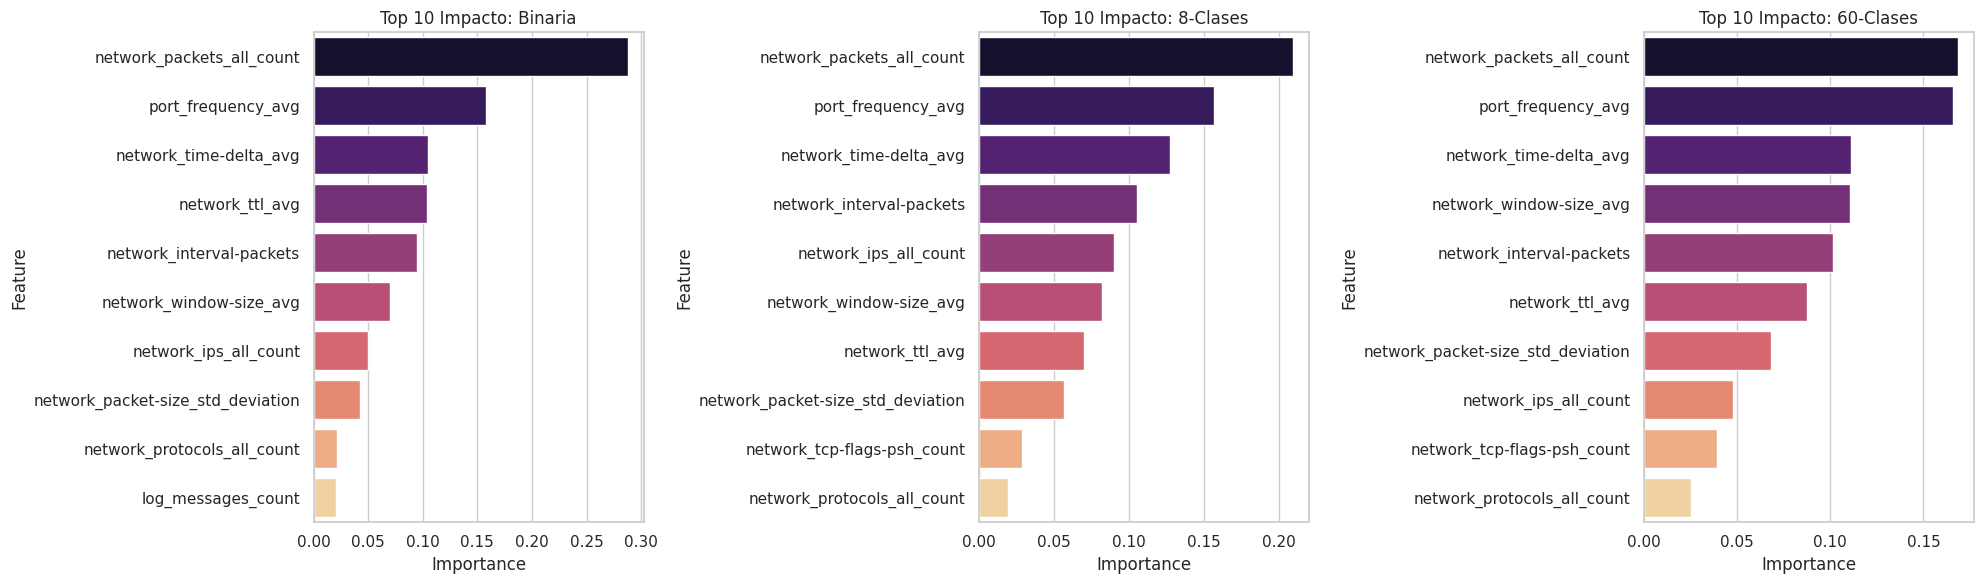

In [6]:
# 1. Reporte Detallado de Hiperparámetros de todos los modelos
print("=== RESUMEN DE HIPERPARÁMETROS POR MODELO ===")
configs = []
for t in tareas:
    for alg in algoritmos:
        if alg in modelos[t]:
            m = modelos[t][alg]
            # Extraemos los parámetros más relevantes para no saturar la vista
            p = m.get_params()
            interesantes = {k: v for k, v in p.items() if k in [
                'n_estimators', 'max_depth', 'n_neighbors', 'hidden_layer_sizes', 
                'activation', 'alpha', 'var_smoothing', 'weights'
            ]}
            configs.append({"Tarea": t, "Algoritmo": alg, "Params": interesantes})

df_params = pd.DataFrame(configs)
display(df_params)

# 2. Importancia de Variables (Específico para RandomForest)
# Nota: kNN y MLP no tienen un atributo directo de importancia tan claro como RF
print("\n=== IMPORTANCIA DE CARACTERÍSTICAS (Basado en RandomForest) ===")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, t in enumerate(tareas):
    if "RandomForest" in modelos[t]:
        rf = modelos[t]["RandomForest"]
        importancias = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': rf.feature_importances_
        }).sort_values(by='Importance', ascending=False).head(10)
        
        sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
        axes[i].set_title(f"Top 10 Impacto: {t}")
plt.tight_layout()
plt.show()

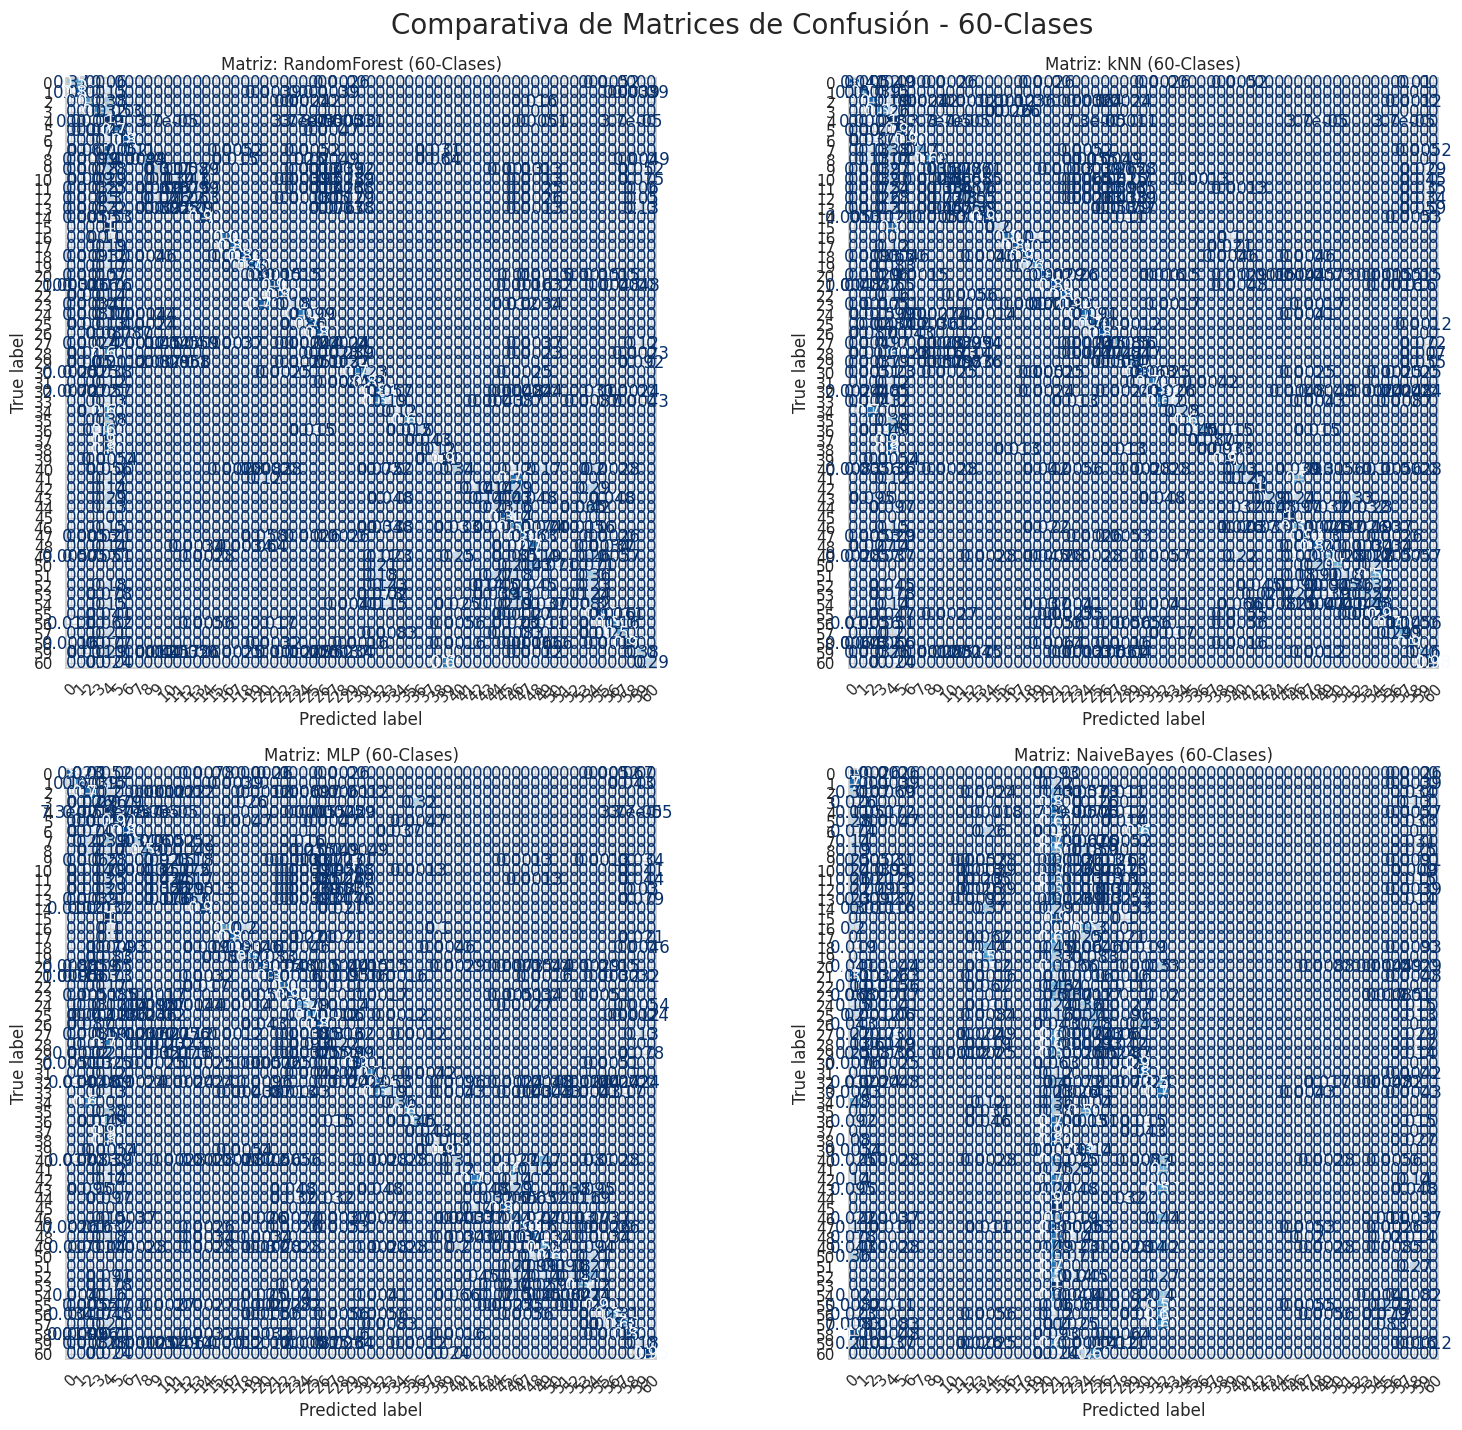

In [9]:
t_eval = "60-Clases"  # Puedes cambiar a "Binaria" o "60-Clases"
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

X_eval_scaled = scalers[t_eval].transform(X_test_raw)
y_real = tareas[t_eval]["y_real"]

for i, alg in enumerate(algoritmos):
    if alg in modelos[t_eval]:
        y_pred = modelos[t_eval][alg].predict(X_eval_scaled)
        
        # Dibujamos la matriz en su sub-gráfico correspondiente
        ConfusionMatrixDisplay.from_predictions(
            y_real, 
            y_pred, 
            cmap='Blues', 
            ax=axes[i], 
            xticks_rotation=45,
            colorbar=False,
            normalize='true'
        )
        axes[i].set_title(f"Matriz: {alg} ({t_eval})")
    else:
        axes[i].set_title(f"Modelo {alg} no encontrado")
        axes[i].axis('off')

plt.tight_layout()
plt.suptitle(f"Comparativa de Matrices de Confusión - {t_eval}", fontsize=20, y=1.02)
plt.show()